In [20]:
from pynq import Overlay
from pynq import allocate
from math import log
import numpy as np
import matplotlib.pyplot as plt
import random
import wave

In [21]:
ol = Overlay('fft_block_design_wrapper.xsa')

In [22]:
ol?

In [23]:
data_dma = ol.fft_block.data_dma
config_dma = ol.fft_block.data_dma

In [24]:
data_send = data_dma.sendchannel
data_recv = data_dma.recvchannel
conf_send = config_dma.sendchannel

In [25]:
def dataConv(fft_direction,size):
    fft_direction.zfill(8) #fills emply spots w/ 0s
    
    byte2 = '0'*8 #all of byte 2 is zeros
    
    x = int(log(size,2))
    fft_size = bin(x)[2:]
    
    fft_size.zfill(8)
    totalData = fft_direction+byte2+fft_size
    return int(totalData,2)

In [26]:
Nsamples = 8192

In [27]:
#wav files are 16 bit real
#allocate for input buffer expects np.csingle which is 64 bit complex (32 real 32 imag)

def wav_to_complex(filename, Nsamples, start_sec=0):
    wav = wave.open(filename, 'rb')

    fs = wav.getframerate()
    wav.setpos(fs * start_sec)  # skip silence at start
    fulldata=[]
    for i in range((wav.getnframes()//Nsamples)):
               
        frames = wav.readframes(Nsamples)
        audio = np.frombuffer(frames, dtype=np.int16).copy()

        if wav.getnchannels() == 2:
            audio = audio[::2]

        audio_f32 = audio.astype(np.float32) / 32768.0
        complex_data = audio_f32.astype(np.csingle)
        fulldata.append(complex_data)           
    return fulldata

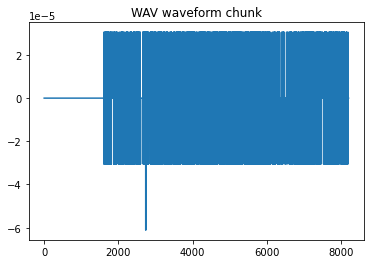

In [28]:
#FOR RANDOM GENERATED DATA

#data,t = genData(Nsamples,interval)
#plt.plot(t,np.real(data))

#FOR WAV DATA

data = wav_to_complex("Communication Breakdown (Remaster).wav", Nsamples)

plt.plot(np.real(data[0]))
plt.title("WAV waveform chunk")
plt.show()

In [29]:
#freq = np.fft.fftfreq(Nsamples*interval,1/Nsamples)

freq = np.fft.fftfreq(Nsamples, 1/44100) #for wav file

In [30]:
#ALLOCATING BUFFER SIZE FOR DMA
#using csingle as fft block expects 64 bit complex values

input_buffer = allocate(Nsamples, np.csingle)
output_buffer = allocate(Nsamples, np.csingle)
all_output = []
for part in data:
    np.copyto(input_buffer, part)
    data_send.transfer(input_buffer)
    data_recv.transfer(output_buffer)
    data_send.wait()
    data_recv.wait()
    all_output.append(np.abs(output_buffer.copy()))
    
all_output = np.concatenate(all_output)
freq = np.fft.fftfreq(Nsamples, 1/44100)
full_freq = np.tile(freq, len(data)) 



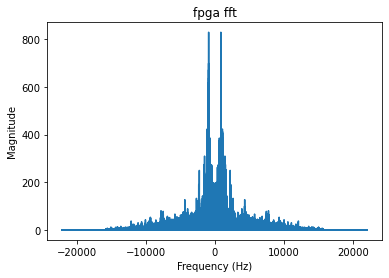

In [31]:
plt.plot(full_freq[:500000], all_output[:500000])
plt.title("fpga fft")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [33]:
combined = np.concatenate(data)[:500000]
npout = np.fft.fft(combined)
npfreq = np.fft.fftfreq(500000, 1/44100)

In [ ]:
plt.plot(npfreq, np.abs(npout))
plt.title("Numpy FFT")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()